# Variational AutoEncoder

We will describe a model involving latent variables, and fit it using ELBO maximization. This analysis is an example of VAE (Variational AutoEncoder). 

In [1]:
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

We will use the MNIST dataset, a standard benchmark dataset consisting of grayscale images of handwritten digits from 0 to 9. The dataset is divided into a training set and a test set, allowing us to fit the model on one collection of images and evaluate its performance on held-out data. Each image is $28 \times 28$ pixels, so it can be represented as a vector in $\mathbb{R}^{784}$. 

In [2]:
train = datasets.MNIST("./_mnist", train=True, download=True)
test = datasets.MNIST("./_mnist", train=False, download=True)
print(train.data.shape)
print(test.data.shape)

100.0%
100.0%
100.0%
100.0%

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


So the training data has 60K images, and the test data has 10K images. Below we look at the pixel-wise data for the first image.  

In [3]:
print(train.data[0])
print("Original shape:", train.data[0].shape)
print("Label:", train.targets[0].item())

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,
          18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

Each image is stored as a 28 $\times$ 28 array of pixel intensities, where each entry is an integer between 0 and 255. A value of 0 represents a black/background pixel, while larger values represent brighter pixels. We will rescale the data for each image by dividing the vector by 255, and then treat the resulting vector as approximately binary. Note also that each image has an associated label that gives the value of the digit shown in the image. For example, for the first image above, the label is 5. We will not use these labels in our analysis. 

To view an image, we can use the following code. 

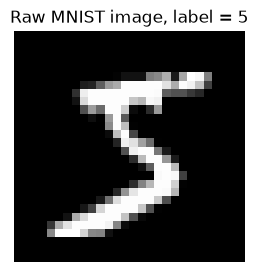

In [4]:
plt.figure(figsize=(3, 3))
r = 0
plt.imshow(train.data[r], cmap="gray")
plt.title(f"Raw MNIST image, label = {train.targets[r].item()}")
plt.axis("off")
plt.show()

Below we create the data vector for each image by dividing the pixel entries by 255 (we will treat these data vectors as approximately binary). 

In [5]:
#note 28 * 28 = 784
Xtr = (train.data.float() / 255.0).view(-1, 784)
ytr = train.targets

Xte = (test.data.float() / 255.0).view(-1, 784)
yte = test.targets

print("train:", Xtr.shape, "test:", Xte.shape)

train: torch.Size([60000, 784]) test: torch.Size([10000, 784])


To the above data (pixel entries divided by 255), we will fit the model: 
\begin{align*}
   y_i \mid z_i \sim \text{Bernoulli}(\sigma(f_{\theta}(z_i))) ~~ \text{ and } ~~ z_i \sim N(0, I_d). 
\end{align*}
where
\begin{align*}
   f_{\theta}(z_i) = B \text{ReLU}(A z_i + a) + b
\end{align*}
with $\theta = (A, a, B, b)$. We will fit $\theta$ by maximizing the ELBO function: 
\begin{align*}
  & \text{ELBO}(\phi, \theta) \\
  &= \frac{1}{L} \sum_{i=1}^n \sum_{l = 1}^L \sum_{j=1}^{d_y}
    \left\{y_{i, j} \log \sigma\left( f_{\theta, j}(\mu_{\phi}(y_i) +
    \sigma_{\phi}(y_i) \odot u_i^{(l)})\right) \right. \\ & \left.+ (1 - y_{i, j}) \log \left[1 -
    \sigma\left( f_{\theta, j}(\mu_{\phi}(y_i) + 
    \sigma_{\phi}(y_i) \odot u_i^{(l)}) \right) 
    \right] \right\} \\
  &- \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^d \left\{\sigma^2_{\phi,
    j}(y_i) + \mu^2_{\phi, j}(y_i) - \log \sigma^2_{\phi, j}(y_i) - 1
    \right\}
\end{align*}
where
\begin{align*}
  &  \mu_{\phi}(y) = W_{\mu} \text{ReLU}(Wy + w) + b_{\mu}  \\
  & \log \sigma^2_{\phi}(y) = W_{\sigma} \text{ReLU}(Wy + w) + b_{\sigma},
\end{align*}
with $\phi = (W_{\mu}, W, w, b_{\mu}, W_{\sigma}, b_{\sigma})$. Here $u_i^{(l)}$ are i.i.d samples from $N(0, I_d)$. 

The function $-\text{ELBO}(\phi, \theta)$ is coded as follows. 


In [6]:
class MNIST_VAE(nn.Module):
    def __init__(self, x_dim=784, z_dim=20, h=400):
        super().__init__()
        self.enc1       = nn.Linear(x_dim, h)
        self.enc_mu     = nn.Linear(h, z_dim)
        self.enc_logvar = nn.Linear(h, z_dim)
        self.dec1       = nn.Linear(z_dim, h)
        self.dec2       = nn.Linear(h, x_dim)

    def encode(self, x):
        h = F.relu(self.enc1(x))
        return self.enc_mu(h), self.enc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        h = F.relu(self.dec1(z))
        return torch.sigmoid(self.dec2(h))         # Bernoulli mean

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss_bernoulli(x, x_rec, mu, logvar):
    bce = F.binary_cross_entropy(x_rec, x, reduction="none").sum(dim=1)
    kl  = 0.5 * (mu.pow(2) + logvar.exp() - 1 - logvar).sum(dim=1)
    return bce.mean(), kl.mean()


Here is the correspondence between the code above and the description of ELBO given just before the code. The code for the function $\text{sigmoid}(f_{\theta}(z))$ is given in the function **decode**. The code for $\mu_{\phi}(y)$ and $\log \sigma^2_{\phi}(y)$ is in the function **encode**. Samples of the form $\mu_{\phi}(y_i) + \sigma_{\phi}(y_i) \odot u_i^{(l)}$ are in the function **reparameterize**. The term **bce** (inside the function 'vae_loss_bernoulli') contains the negative of the Bernoulli log-likelihood, and the **kl** term corresponds to the KL term in the formula for the negative ELBO. Note that the final loss function corresponds to our formula above for $L = 1$. 

The parameters are trained in the code below. Note that $L = 1$ is being employed here. So the code samples only one $u_i$ for each $y_i$ during each forward pass. This does **not** mean the model only ever sees one latent draw for each image. Across epochs, and even across different visits of the same image, the code draws a fresh $u_i$. So over training, the stochastic gradients are still averaging over many random draws implicitly. In each individual gradient update, however, the Monte Carlo estimate uses $L = 1$. 

In [7]:
# --- train MNIST VAE on CPU ---
mnist_model = MNIST_VAE()

opt = torch.optim.Adam(mnist_model.parameters(), lr=1e-3)

dl_tr = DataLoader(TensorDataset(Xtr), batch_size=128, shuffle=True)

EPOCHS = 40

vae_history = []
vae_rec_history = []
vae_kl_history = []

for epoch in range(EPOCHS):
    rec_e, kl_e, n = 0.0, 0.0, 0

    for (xb,) in dl_tr:
        x_rec, mu, logvar = mnist_model(xb)

        rec, kl = vae_loss_bernoulli(xb, x_rec, mu, logvar)
        loss = rec + kl

        opt.zero_grad()
        loss.backward()
        opt.step()

        rec_e += rec.item() * xb.size(0)
        kl_e  += kl.item()  * xb.size(0)
        n     += xb.size(0)

    avg_rec = rec_e / n
    avg_kl = kl_e / n
    avg_neg_elbo = (rec_e + kl_e) / n

    vae_rec_history.append(avg_rec)
    vae_kl_history.append(avg_kl)
    vae_history.append(avg_neg_elbo)

    print(
        f"epoch {epoch+1:2d}  "
        f"rec={avg_rec:.2f}  "
        f"kl={avg_kl:.2f}  "
        f"-ELBO={avg_neg_elbo:.2f}"
    )

epoch  1  rec=148.78  kl=15.67  -ELBO=164.45
epoch  2  rec=98.60  kl=22.75  -ELBO=121.35
epoch  3  rec=90.31  kl=24.26  -ELBO=114.57
epoch  4  rec=86.92  kl=24.75  -ELBO=111.67
epoch  5  rec=84.92  kl=24.94  -ELBO=109.87
epoch  6  rec=83.68  kl=25.08  -ELBO=108.77
epoch  7  rec=82.73  kl=25.21  -ELBO=107.94
epoch  8  rec=82.04  kl=25.24  -ELBO=107.28
epoch  9  rec=81.41  kl=25.29  -ELBO=106.71
epoch 10  rec=81.00  kl=25.33  -ELBO=106.33
epoch 11  rec=80.58  kl=25.38  -ELBO=105.96
epoch 12  rec=80.26  kl=25.43  -ELBO=105.69
epoch 13  rec=80.00  kl=25.46  -ELBO=105.46
epoch 14  rec=79.71  kl=25.47  -ELBO=105.18
epoch 15  rec=79.50  kl=25.47  -ELBO=104.98
epoch 16  rec=79.26  kl=25.50  -ELBO=104.75
epoch 17  rec=79.10  kl=25.50  -ELBO=104.60
epoch 18  rec=78.90  kl=25.50  -ELBO=104.40
epoch 19  rec=78.75  kl=25.52  -ELBO=104.27
epoch 20  rec=78.61  kl=25.50  -ELBO=104.10
epoch 21  rec=78.48  kl=25.53  -ELBO=104.01
epoch 22  rec=78.39  kl=25.52  -ELBO=103.91
epoch 23  rec=78.22  kl=25.52  

We now have estimates of $\theta$ as well as $\phi$. For each $i$, we can now produce an estimate of $\hat{p}_i$ as follows. First generate $z_i$ from the Gaussian distribution with mean $\mu_{\phi}(y_i)$ and covariance $\Sigma_{\phi}(y_i)$. Then calculate $\hat{p}_i = \text{sigmoid}(f_{\theta}(z_i))$. We can plot $\hat{p}_i$ for each $i$. We can also generate new $y_i$ using $\hat{p}_i$ by simulating from the Bernoulli distribution with probability $\hat{p}_i$. Below, we do this for 8 randomly generated values of $i$. 

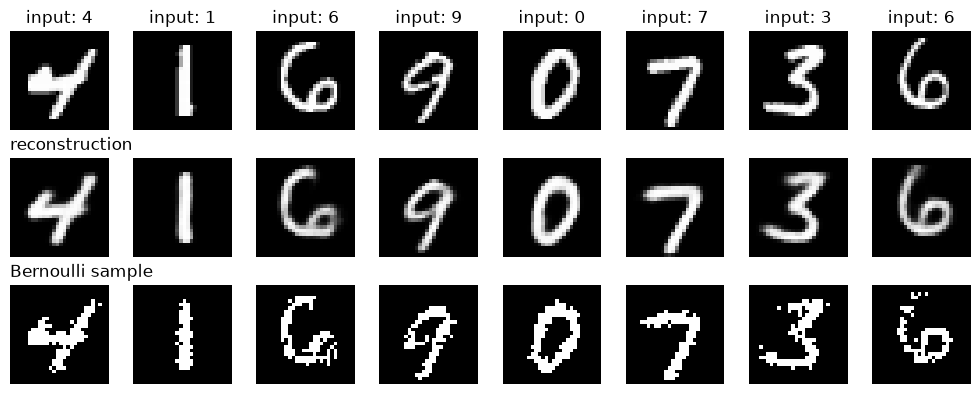

In [8]:
mnist_model.eval()

with torch.no_grad():
    # Randomly choose 8 test images
    idx = torch.randperm(Xte.shape[0])[:8]
    xb = Xte[idx]
    labels = yte[idx]

    # Decoder output: \hat{p}_i
    x_rec, _, _ = mnist_model(xb)

    # Bernoulli sample: \tilde{y}_i ~ Bernoulli(\hat{y}_i)
    x_sample = torch.bernoulli(x_rec)

fig, ax = plt.subplots(3, 8, figsize=(10, 4))

for j in range(8):
    ax[0, j].imshow(xb[j].view(28, 28), cmap="gray")
    ax[0, j].set_title(f"input: {labels[j].item()}")
    ax[0, j].axis("off")

    ax[1, j].imshow(x_rec[j].view(28, 28), cmap="gray")
    ax[1, j].axis("off")

    ax[2, j].imshow(x_sample[j].view(28, 28), cmap="gray")
    ax[2, j].axis("off")

ax[1, 0].set_title("reconstruction", loc="left")
ax[2, 0].set_title("Bernoulli sample", loc="left")

plt.tight_layout()
plt.show()

Below we use the fitted model to generate new images. We first generate $z \sim N(0, I_d)$, then we use simply calculate $\text{sigmoid}(f_{\theta}(z))$. We repeat this process for a bunch of times and plot the resulting images. 

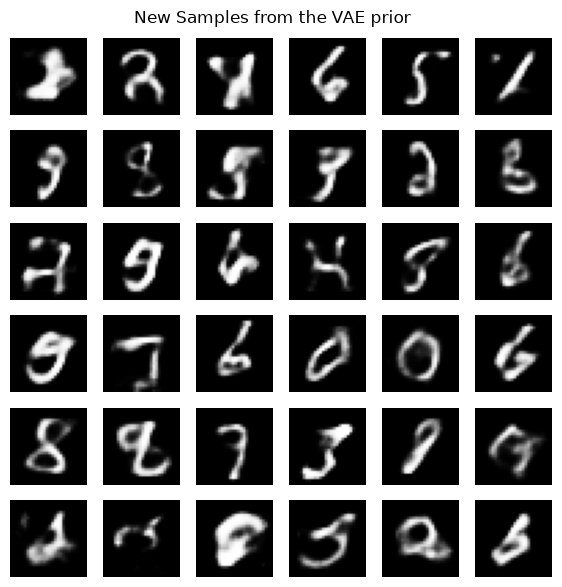

In [9]:
with torch.no_grad():
    z = torch.randn(36, 20)
    x_gen = mnist_model.decode(z)

fig, ax = plt.subplots(6, 6, figsize=(7, 7))
for i, a in enumerate(ax.flat):
    a.imshow(x_gen[i].view(28, 28), cmap="gray")
    a.axis("off")

plt.suptitle("New Samples from the VAE prior", y=0.92)
plt.show()

Given two images (say $y_1$ and $y_2$), we can interpolate between them using the fitted model. We first compute $z_i \sim N(\mu_{\phi}(y_i), \Sigma_{\phi}(y_i))$ and then calculate $z(t) = (1 - t) z_1 + t z_2$. Then we convert each $z(t)$ back to an image using the code $\text{sigmoid}(f_{\theta}(z(t)))$. Implementation of this is given below. 

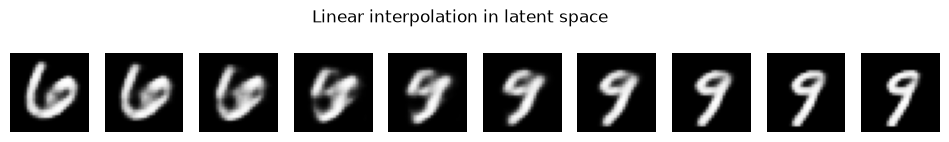

In [10]:
mnist_model.eval()

with torch.no_grad():
    num1 = 6
    num2 = 9

    idx_num1 = (yte == num1).nonzero(as_tuple=True)[0]
    idx_num2 = (yte == num2).nonzero(as_tuple=True)[0]

    i_num1 = idx_num1[torch.randint(len(idx_num1), (1,))].item()
    i_num2 = idx_num2[torch.randint(len(idx_num2), (1,))].item()
    
    x1, x2 = Xte[i_num1], Xte[i_num2]

    mu1, _ = mnist_model.encode(x1.unsqueeze(0))
    mu2, _ = mnist_model.encode(x2.unsqueeze(0))

    ts = torch.linspace(0, 1, 10).view(-1, 1)
    zs = (1 - ts) * mu1 + ts * mu2
    xs = mnist_model.decode(zs)

fig, ax = plt.subplots(1, 10, figsize=(12, 1.5))
for i, a in enumerate(ax):
    a.imshow(xs[i].view(28, 28), cmap="gray")
    a.axis("off")

plt.suptitle("Linear interpolation in latent space", y=1.05)
plt.show()

Note that this interpolation looks very natural as the image moves from one number to the other. Instead, if we had interpolated directly on the images as $(1 - t) y_1 + t y_2$, the images will look non-realistic in the middle. Here is the comparison with both the kinds of interpolation. 

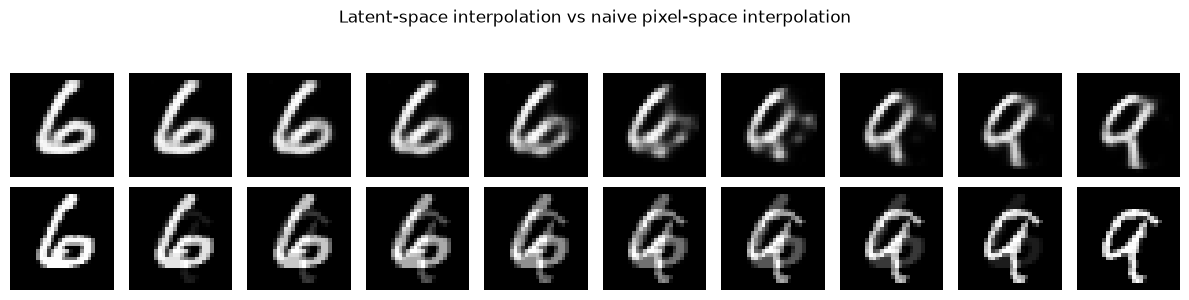

In [11]:
mnist_model.eval()

with torch.no_grad():
    num1 = 6
    num2 = 9

    idx_num1 = (yte == num1).nonzero(as_tuple=True)[0]
    idx_num2 = (yte == num2).nonzero(as_tuple=True)[0]

    i_num1 = idx_num1[torch.randint(len(idx_num1), (1,))].item()
    i_num2 = idx_num2[torch.randint(len(idx_num2), (1,))].item()
    
    y1, y2 = Xte[i_num1], Xte[i_num2]

    # Latent-space interpolation
    mu1, _ = mnist_model.encode(y1.unsqueeze(0))
    mu2, _ = mnist_model.encode(y2.unsqueeze(0))

    ts = torch.linspace(0, 1, 10).view(-1, 1)

    zs = (1 - ts) * mu1 + ts * mu2
    ys_latent = mnist_model.decode(zs)

    # Naive pixel-space interpolation
    ys_naive = (1 - ts) * y1 + ts * y2

fig, ax = plt.subplots(2, 10, figsize=(12, 3))

for i in range(10):
    ax[0, i].imshow(ys_latent[i].view(28, 28), cmap="gray")
    ax[0, i].axis("off")

    ax[1, i].imshow(ys_naive[i].view(28, 28), cmap="gray")
    ax[1, i].axis("off")

ax[0, 0].set_ylabel("latent", rotation=0, labelpad=25)
ax[1, 0].set_ylabel("pixel", rotation=0, labelpad=25)

plt.suptitle("Latent-space interpolation vs naive pixel-space interpolation", y=1.02)
plt.tight_layout()
plt.show()

Another application of this model is to do denoising of an image with noise. Given a noisy image $y$, we first transform it into the latent space using $z \sim N(\mu_{\phi}(y), \Sigma_{\phi}(y))$, and then re-create $y$ using $\text{sigmoid}(f_{\theta}(z))$. This can take care of some noise in the original image, as shown below. The noise added here involves taking some pixels and flipping their pixel value (from 0 to 1 and vice versa). 

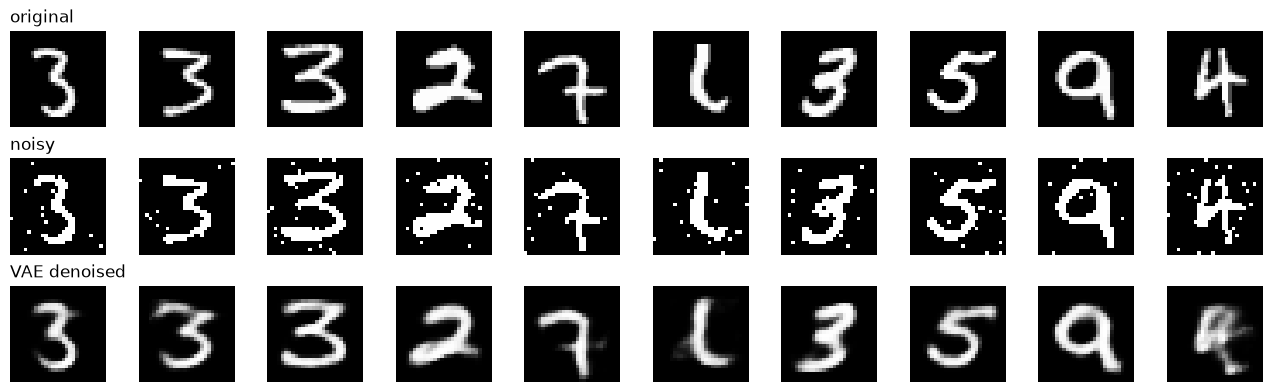

In [12]:
# ------------------------------------------------------------
# Denoising MNIST images using the fitted VAE
# ------------------------------------------------------------

mnist_model.eval()

# Number of test images to show
n_show = 10

# Probability of flipping each pixel
flip_prob = 0.02

# Take n_show random test images
idx = torch.randperm(Xte.shape[0])[:n_show]
x_clean = Xte[idx]

# Make random 0/1 flip mask
flip_mask = torch.rand_like(x_clean) < flip_prob

# Since MNIST pixels are grayscale in [0,1], first binarize for clean flipping
x_binary = (x_clean > 0.5).float()

# Flip selected pixels: 0 -> 1 and 1 -> 0
x_noisy = x_binary.clone()
x_noisy[flip_mask] = 1.0 - x_noisy[flip_mask]

with torch.no_grad():
    # Encode noisy image and decode it
    # This gives the VAE reconstruction/denoised image
    x_denoised, mu, logvar = mnist_model(x_noisy)

fig, ax = plt.subplots(3, n_show, figsize=(1.3 * n_show, 4.0))

for j in range(n_show):
    ax[0, j].imshow(x_clean[j].view(28, 28), cmap="gray")
    ax[0, j].axis("off")

    ax[1, j].imshow(x_noisy[j].view(28, 28), cmap="gray")
    ax[1, j].axis("off")

    ax[2, j].imshow(x_denoised[j].view(28, 28), cmap="gray")
    ax[2, j].axis("off")

ax[0, 0].set_title("original", loc="left")
ax[1, 0].set_title("noisy", loc="left")
ax[2, 0].set_title("VAE denoised", loc="left")

plt.tight_layout()
plt.show()

Each image $y_i$ can be mapped to the latent $d$-dimensional Euclidean space through $z_i \sim N(\mu_{\phi}(y_i), \Sigma_{\phi}(y_i))$. It is natural to see if $z_1, \dots, z_n$ have any structure related to the labels. For example, are all the images corresponding to the number 6 clustered in one group (which is separate from the cluster corresponding to images with number 5 etc.). To check this, we can use some clustering algorithm on $z_1, \dots, z_n$. We do this below using the t-SNE algorithm for clustering. The following code is crashing the Jupyter kernel on my laptop (but it is working well on my desktop). 

In [15]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 8.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


Latent mean shape: (3000, 20)


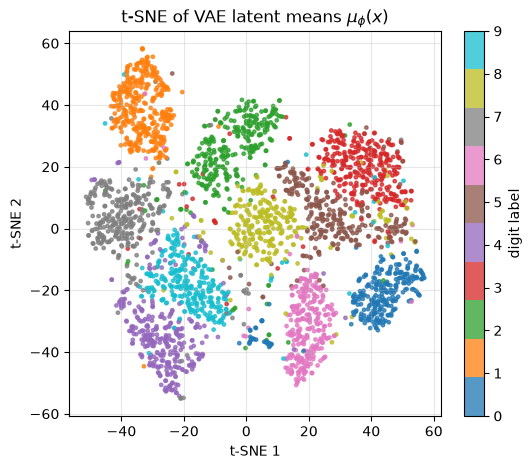

In [16]:
from sklearn.manifold import TSNE

# ------------------------------------------------------------
# 1. Encode test images into latent means
# ------------------------------------------------------------

mnist_model.eval()

n_plot = 3000   # t-SNE can be slow, so use a subset of test images

X_sub = Xte[:n_plot]
y_sub = yte[:n_plot].numpy()


with torch.no_grad():
    mu_z, logvar_z = mnist_model.encode(X_sub)

# Convert latent means to NumPy
Z_mu = mu_z.numpy()

print("Latent mean shape:", Z_mu.shape)
# Should be (n_plot, 20) if z_dim = 20


# ------------------------------------------------------------
# 2. Run t-SNE on the latent means
# ------------------------------------------------------------

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=0
)

Z_tsne = tsne.fit_transform(Z_mu)


# ------------------------------------------------------------
# 3. Plot t-SNE projection colored by digit labels
# ------------------------------------------------------------

plt.figure(figsize=(6, 5))

sc = plt.scatter(
    Z_tsne[:, 0],
    Z_tsne[:, 1],
    c=y_sub,
    s=6,
    cmap="tab10",
    alpha=0.75
)

plt.colorbar(sc, label="digit label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE of VAE latent means $\\mu_\\phi(x)$")
plt.grid(alpha=0.3)
plt.show()

It is clear that there is a nice clustering pattern (with regard to the labels) for the latent values $z_1, \dots, z_n$. This shows that the model is learning hidden structure related to the labels. 

## Direct Method for fitting the model

In the above code, we fit the following model by maximizing the ELBO: 
\begin{align*}
   y_i \mid z_i \sim \text{Bernoulli}(\sigma(f_{\theta}(z_i))) ~~ \text{ and } ~~ z_i \sim N(0, I_d). 
\end{align*}
where
\begin{align*}
   f_{\theta}(z_i) = B \text{ReLU}(A z_i + a) + b
\end{align*}
with $\theta = (A, a, B, b)$. 

Now we will fit the model by direct maximum likelihood, approximated using Monte Carlo. In other words, we use the approximation: 
\begin{align*}
  \log f_{\text{data} \mid \theta}(y_1, \dots, y_n) \approx \sum_{i=1}^n \log \left[\frac{1}{M} \sum_{l=1}^M p_{\theta}(y_i \mid z_i^{(l)}) \right]
\end{align*}
where $p_{\theta}(y \mid z) = (\sigma(f_{\theta}(z)))^y (1 - \sigma(f_{\theta}(z)))^{1-y}$. In the code below, we use $M = 64$. 

In [17]:

class DirectBernoulliDecoder(nn.Module):
    def __init__(self, x_dim=784, z_dim=20, h=400):
        super().__init__()
        self.z_dim = z_dim
        self.dec1 = nn.Linear(z_dim, h)
        self.dec2 = nn.Linear(h, x_dim)

    def logits(self, z):
        h = F.relu(self.dec1(z))
        return self.dec2(h)

    def decode(self, z):
        return torch.sigmoid(self.logits(z))


def log_bernoulli_prob_from_logits(x, logits):
    """
    Compute log p(x | z) for every pair in a batch of x's and z's.

    x:      shape (B, D)
    logits: shape (M, D), where pi_theta(z_m) = sigmoid(logits[m])

    returns:
        log_probs with shape (B, M), where entry (i, m) is log p_theta(x_i | z_m).
    """
    # -binary_cross_entropy_with_logits gives
    # sum_j x_j log sigmoid(logit_j) + (1-x_j) log(1-sigmoid(logit_j)).
    x_expanded = x[:, None, :]           # (B, 1, D)
    logits_expanded = logits[None, :, :] # (1, M, D)

    log_prob = -F.binary_cross_entropy_with_logits(
        logits_expanded.expand(x.shape[0], -1, -1),
        x_expanded.expand(-1, logits.shape[0], -1),
        reduction="none"
    ).sum(dim=2)

    return log_prob


def mc_marginal_loglik(x, model, M=16, z_fixed=None):
    """
    Monte Carlo approximation to log p_theta(x_i), for each row x_i.

    If z_fixed is supplied, it is reused. Reusing z_fixed gives a deterministic
    approximate objective. Drawing new z each time gives an unbiased estimate
    of the likelihood integral but a noisier training objective.
    """
    if z_fixed is None:
        z = torch.randn(M, model.z_dim, device=x.device)
    else:
        z = z_fixed.to(x.device)

    logits = model.logits(z)                  # (M, 784)
    log_p_x_given_z = log_bernoulli_prob_from_logits(x, logits)  # (B, M)

    # log mean_m exp(log p(x | z_m))
    return torch.logsumexp(log_p_x_given_z, dim=1) - math.log(z.shape[0])


def train_direct_decoder(
    X_train,
    z_dim=20,
    h=400,
    M=16,
    batch_size=256,
    epochs=5,
    lr=1e-3,
    fixed_mc_samples=True,
    random_seed=0
):
    """
    Maximize the Monte Carlo approximation to the marginal likelihood.

    Important: this is usually much harder than VAE training. For classroom
    speed, start with epochs=5 and M=16. Larger M gives a better likelihood
    approximation but is slower.
    """
    torch.manual_seed(random_seed)

    model = DirectBernoulliDecoder(x_dim=784, z_dim=z_dim, h=h)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    dl = DataLoader(TensorDataset(X_train), batch_size=batch_size, shuffle=True)

    z_fixed = None
    if fixed_mc_samples:
        z_fixed = torch.randn(M, z_dim)

    history = []

    for epoch in range(epochs):
        total_nll, n = 0.0, 0

        for (xb,) in dl:
            loglik_i = mc_marginal_loglik(xb, model, M=M, z_fixed=z_fixed)
            nll = -loglik_i.mean()

            opt.zero_grad()
            nll.backward()
            opt.step()

            total_nll += nll.item() * xb.size(0)
            n += xb.size(0)

        avg_nll = total_nll / n
        history.append(avg_nll)
        print(f"direct epoch {epoch+1:2d}  MC marginal NLL={avg_nll:.2f}")

    return model, history


# Fit the direct model to the same training data Xtr.
# This can be slower than VAE training because every image is compared with M latent samples.
direct_model, direct_history = train_direct_decoder(
    Xtr,
    z_dim=20,
    h=400,
    M=64,
    batch_size=256,
    epochs=40,
    lr=1e-3,
    fixed_mc_samples=True,
    random_seed=0
)


direct epoch  1  MC marginal NLL=186.81
direct epoch  2  MC marginal NLL=151.57
direct epoch  3  MC marginal NLL=147.56
direct epoch  4  MC marginal NLL=145.56
direct epoch  5  MC marginal NLL=144.54
direct epoch  6  MC marginal NLL=144.02
direct epoch  7  MC marginal NLL=143.69
direct epoch  8  MC marginal NLL=143.46
direct epoch  9  MC marginal NLL=143.31
direct epoch 10  MC marginal NLL=143.16
direct epoch 11  MC marginal NLL=143.04
direct epoch 12  MC marginal NLL=142.91
direct epoch 13  MC marginal NLL=142.77
direct epoch 14  MC marginal NLL=142.67
direct epoch 15  MC marginal NLL=142.62
direct epoch 16  MC marginal NLL=142.55
direct epoch 17  MC marginal NLL=142.51
direct epoch 18  MC marginal NLL=142.47
direct epoch 19  MC marginal NLL=142.43
direct epoch 20  MC marginal NLL=142.41
direct epoch 21  MC marginal NLL=142.39
direct epoch 22  MC marginal NLL=142.36
direct epoch 23  MC marginal NLL=142.32
direct epoch 24  MC marginal NLL=142.30
direct epoch 25  MC marginal NLL=142.27


The method above also gives an estimate of $\theta$. Below we compare the performance of this direct method with that of VAE. We  create new samples by first generating $z \sim N(0, I_d)$ and then calculating $\text{sigmoid}(f_{\hat{\theta}}(z))$. The only difference between the two methods is $\hat{\theta}$. 

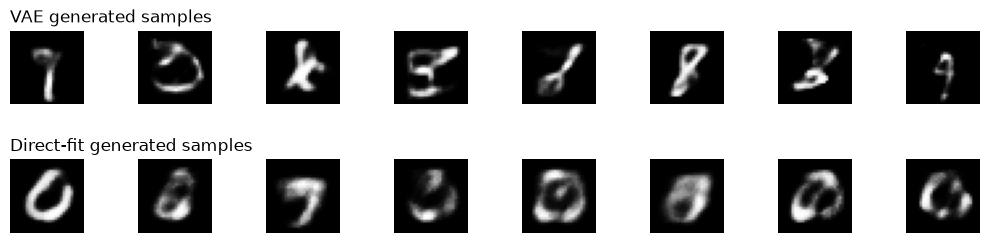

In [18]:

# ------------------------------------------------------------
# Visual comparison of generated samples from both fitted decoders
# ------------------------------------------------------------

mnist_model.eval()
direct_model.eval()

with torch.no_grad():
    z = torch.randn(8, 20)
    x_gen_vae = mnist_model.decode(z)
    x_gen_direct = direct_model.decode(z)

fig, ax = plt.subplots(2, 8, figsize=(10, 2.8))

for j in range(8):
    ax[0, j].imshow(x_gen_vae[j].view(28, 28), cmap="gray")
    ax[0, j].axis("off")

    ax[1, j].imshow(x_gen_direct[j].view(28, 28), cmap="gray")
    ax[1, j].axis("off")

ax[0, 0].set_title("VAE generated samples", loc="left")
ax[1, 0].set_title("Direct-fit generated samples", loc="left")

plt.tight_layout()
plt.show()


Next we start with some $y$, and then use it to first generate $z$ and then back to $\tilde{y}$, which can be considered as a denoised version of $y$. In the VAE, this is easy to do because $z$ can be generated by simply sampling from $N(\mu_{\phi}(y), \Sigma_{\phi}(y))$ (this distribution is called the encoder). Now there is no such simple form for the encoder. Instead, we need to sample $z$ from the posterior: 
\begin{align*}
    \propto \varphi(z) p_{\theta}(y \mid z). 
\end{align*}
To sample from this posterior, we generate a large number of samples $z_1, \dots, z_M$ from $N(0, I_d)$, and then pick $z_m$ for which $p_{\theta}(y \mid z_m)$ is the largest. 

Once $z$ is generated, we simply calculate $\text{sigmoid}(f_{\theta}(z))$. 

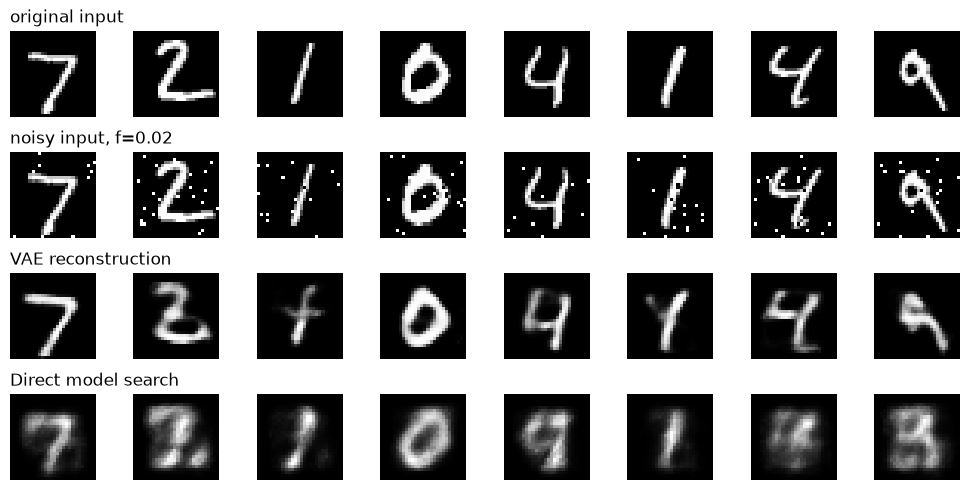

In [19]:
# ------------------------------------------------------------
# Reconstruction comparison with pixel-flip noise
# ------------------------------------------------------------
# The direct model has no encoder, so it cannot reconstruct by encoding x.
# To reconstruct an image under the direct model, we search over candidate z's
# and choose the z that gives the largest p_theta(x | z).
#
# This is deliberately slower and less elegant than the VAE encoder.

def direct_reconstruct_by_prior_search(model, x, M=20000):
    """
    For each image x_i, draw M prior candidates z_m and pick
    argmax_m p_theta(x_i | z_m). This gives a crude reconstruction
    for the direct model.
    """
    model.eval()

    with torch.no_grad():
        z = torch.randn(M, model.z_dim)
        logits = model.logits(z)
        log_probs = log_bernoulli_prob_from_logits(x, logits)  # (B, M)
        best = log_probs.argmax(dim=1)
        x_rec = torch.sigmoid(logits[best])

    return x_rec


# ------------------------------------------------------------
# Pixel-flip noise function
# ------------------------------------------------------------

def add_pixel_flip_noise(x, f=0.01):
    """
    Flip each pixel independently with probability f.

    If x_ij is close to 0, it becomes close to 1.
    If x_ij is close to 1, it becomes close to 0.
    """
    flip_mask = torch.bernoulli(f * torch.ones_like(x))
    x_noisy = torch.where(flip_mask == 1, 1.0 - x, x)
    return x_noisy


n_show = 8
f = 0.02

xb = Xte[:n_show]

# Add pixel-flip noise before reconstruction
xb_noisy = add_pixel_flip_noise(xb, f=f)

with torch.no_grad():
    x_rec_vae, _, _ = mnist_model(xb_noisy)

x_rec_direct = direct_reconstruct_by_prior_search(direct_model, xb_noisy, M=20000)


fig, ax = plt.subplots(4, n_show, figsize=(10, 5.0))

for j in range(n_show):
    ax[0, j].imshow(xb[j].view(28, 28), cmap="gray")
    ax[0, j].axis("off")

    ax[1, j].imshow(xb_noisy[j].view(28, 28), cmap="gray")
    ax[1, j].axis("off")

    ax[2, j].imshow(x_rec_vae[j].view(28, 28), cmap="gray")
    ax[2, j].axis("off")

    ax[3, j].imshow(x_rec_direct[j].view(28, 28), cmap="gray")
    ax[3, j].axis("off")

ax[0, 0].set_title("original input", loc="left")
ax[1, 0].set_title(f"noisy input, f={f}", loc="left")
ax[2, 0].set_title("VAE reconstruction", loc="left")
ax[3, 0].set_title("Direct model search", loc="left")

plt.tight_layout()
plt.show()

It is clear that the reconstruction from direct model search is somewhat worse compared to the VAE reconstruction. This goes back to the reason given in class about the direct Monte Carlo approach being a poor approximator of the actual likelihood. 